In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import seaborn as sns

In [154]:
# import CSV from same folder as assignment_3.ipynb and convert string dates to datetime objects
ob = pd.read_csv("ob_report_2024.csv", parse_dates=['Date Outbreak Began', 'Date Declared Over'])

# ensure dates are now in datetime format
ob.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   _id                  1032 non-null   int64         
 1   Institution Name     1032 non-null   object        
 2   Institution Address  1032 non-null   object        
 3   Outbreak Setting     1032 non-null   object        
 4   Type of Outbreak     1032 non-null   object        
 5   Causative Agent-1    1032 non-null   object        
 6   Causative Agent-2    43 non-null     object        
 7   Date Outbreak Began  1032 non-null   datetime64[ns]
 8   Date Declared Over   1032 non-null   datetime64[ns]
 9   Active               1032 non-null   object        
dtypes: datetime64[ns](2), int64(1), object(7)
memory usage: 80.8+ KB


In [161]:
# Calculate duration of each outbreak in days and convert to integer
ob['Outbreak Days'] = (ob['Date Declared Over']-ob['Date Outbreak Began']).dt.days
ob.info()
ob.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   _id                  1032 non-null   int64         
 1   Institution Name     1032 non-null   object        
 2   Institution Address  1032 non-null   object        
 3   Outbreak Setting     1032 non-null   object        
 4   Type of Outbreak     1032 non-null   object        
 5   Causative Agent-1    1032 non-null   object        
 6   Causative Agent-2    43 non-null     object        
 7   Date Outbreak Began  1032 non-null   datetime64[ns]
 8   Date Declared Over   1032 non-null   datetime64[ns]
 9   Active               1032 non-null   object        
 10  Outbreak Duration    1032 non-null   int64         
 11  Outbreak Days        1032 non-null   int64         
dtypes: datetime64[ns](2), int64(3), object(7)
memory usage: 96.9+ KB


,_id,Institution Name,Institution Address,Outbreak Setting,Type of Outbreak,Causative Agent-1,Causative Agent-2,Date Outbreak Began,Date Declared Over,Active,Outbreak Duration,Outbreak Days
0,1,Baycrest Hospital - H7E,3560 Bathurst St,Hospital-Chronic Care,Respiratory,COVID-19,NaN,2024-12-31,2025-01-11,N,11,11
1,2,Bradgate Arms,54 Foxbar Rd,Retirement Home,Respiratory,COVID-19,NaN,2024-12-31,2025-01-14,N,14,14
2,3,"Chartwell Scarlett Heights - 3rd, 7th & 8th Fl",4005 Eglinton Ave W,Retirement Home,Respiratory,COVID-19,NaN,2024-12-31,2025-01-10,N,10,10
3,4,Cheltenham Care Community - 1st & 3rd Fl,5935 Bathurst St,LTCH,Respiratory,Influenza A (H1N1),NaN,2024-12-31,2025-01-11,N,11,11
4,5,Copernicus Lodge - 6th Fl,66 Roncesvalles Ave,LTCH,Respiratory,COVID-19,NaN,2024-12-31,2025-01-08,N,8,8


In [162]:
ob['Type of Outbreak'].value_counts()
ob['Outbreak Days'].value_counts()

Outbreak Days
8     110
7      90
9      87
11     67
10     67
13     67
14     63
15     58
12     56
17     43
6      42
16     40
18     34
20     26
5      22
21     20
19     17
22     17
23     16
24     15
25     13
4      11
27      9
26      5
2       4
28      3
33      3
36      3
34      3
29      2
39      2
35      2
37      2
32      2
30      2
3       2
40      1
1       1
38      1
57      1
31      1
42      1
47      1
Name: count, dtype: int64

In [131]:
# code to wrap axis labels, from https://medium.com/dunder-data/automatically-wrap-graph-labels-in-matplotlib-and-seaborn-a48740bc9ce
import textwrap
def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)


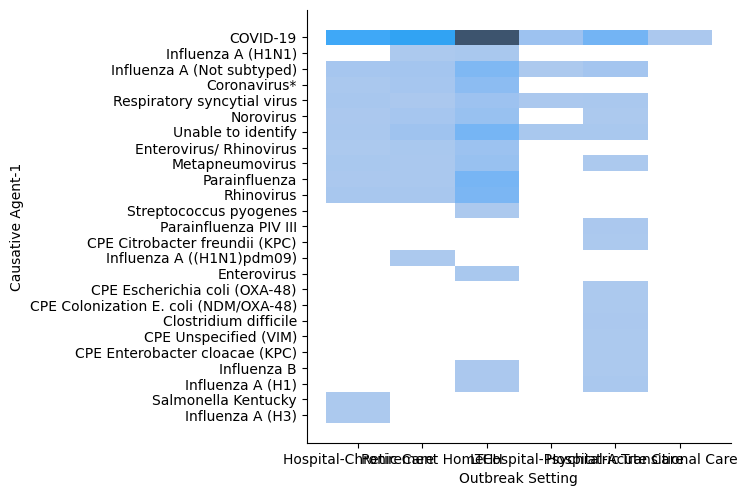

In [ ]:
wrap_labels(ax, 10)
ax.figure

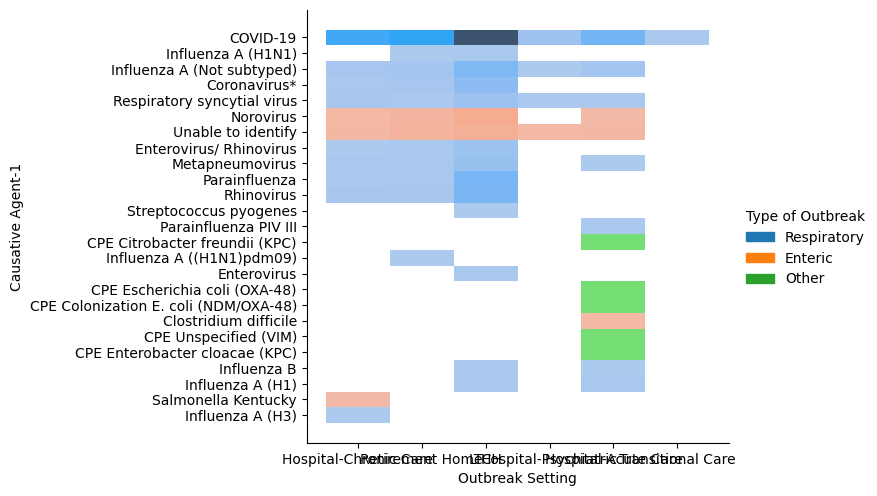

In [143]:
sns.pairplot(data=df,
             hue = "Type of Outbreak",
             x_vars=["Outbreak Setting"],
             y_vars = ["Causative Agent-1"],
             kind = "hist",
             height=5, aspect = 1.5)



<Axes: xlabel='Outbreak Days', ylabel='Outbreak Setting'>

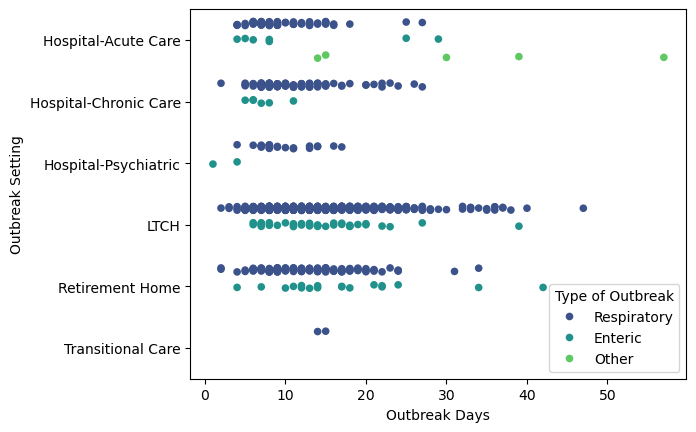

In [194]:
sns.stripplot(ob, y = "Outbreak Setting",
              order = ["Hospital-Acute Care","Hospital-Chronic Care","Hospital-Psychiatric","LTCH","Retirement Home","Transitional Care"],
              size=5.5,
              x = "Outbreak Days",
              hue = "Type of Outbreak",
              dodge = True,
              palette="viridis")

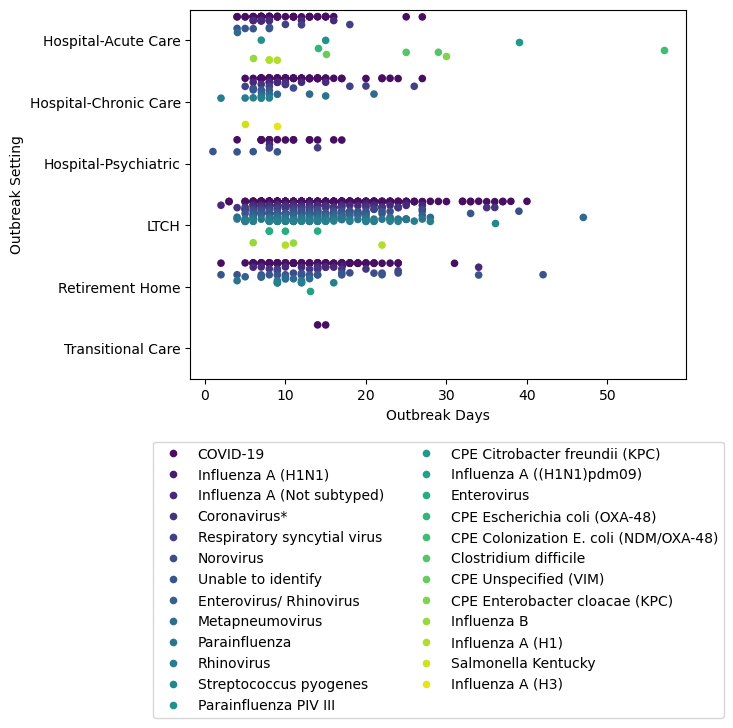

In [196]:
sns.stripplot(ob, y = "Outbreak Setting",
              order = ["Hospital-Acute Care","Hospital-Chronic Care","Hospital-Psychiatric","LTCH","Retirement Home","Transitional Care"],
              size=5.5,
              x = "Outbreak Days",
              hue = "Causative Agent-1",
              dodge = True,
              palette='viridis')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)